# Copernicus Climate Data Store (CDS) access using xcube

This notebook provides a walk-through demonstrating how to use xcube and the xcube Climate Data Store (CDS) plugin to read and explore [drought indices data from the CDS](https://cds.climate.copernicus.eu/datasets/derived-drought-historical-monthly?tab=overview).

Before using this notebook, ensure that you have set up xcube, the CDS plugin, and Jupyter Lab as described in the [Ex0-CDS-store-Setup](./Ex0-CDS-store-setup.ipynb) notebook.

First, we import some necessary libraries.

In [1]:
from xcube.core.store import new_data_store
import shapely.geometry
import IPython.display

Configure matplotlib to display graphs inline directly in the notebook and set a sensible default figure size.

Create a CDS data store object. The optional `normalize_names` parameter specifies that variable names in returned data cubes will be converted to legal Python identifiers, if required.

In [2]:
cds_store = new_data_store("cds", normalize_names=True)

Find out which datasets are available from this store. We get a list of tuples; the first member of each tuple is the data ID, and the second member is a short description of the dataset. We pick `"derived-drought-historical-monthly:reanalysis"`.

In [3]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-land',
 'reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels-timeseries',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-soil-moisture:root-zone-volumetric:daily',
 'satellite-soil-moisture:root-zone-volumetric:10-day',
 'satellite-soil-moisture:root-zone-volumetric:monthly',
 'satellite-soil-moisture:freeze-thaw:daily',
 'satellite-sea-ice-t

In [4]:
data_id = "derived-drought-historical-monthly:reanalysis"

Let's see what parameters we can specify when opening the dataset. Four are listed as required parameters: `time_range`, `bbox`, `accumulation_periods` and `variable_names`. The enumeration in `properties → variable_names → items` lists the 5 variables we can request. 

In [5]:
cds_store.get_open_data_params_schema(data_id)

We can request any number of variables, but for this example we will look at `standardised_precipitation_index` and its two quality datasets.

In [6]:
variable_names = [
    "standardised_precipitation_index",
    "standardised_precipitation_evapotranspiration_index",
    "probability_of_zero_precipitation_spi",
    "test_for_normality_spi",
    "test_for_normality_spei",
]

Next we can request multiple accumulation periods.

In [7]:
accumulation_periods = [1, 3, 6]

Define the bounding box for the area of interest. For this example, we will be using the mid-latitudes of Europe.

In [8]:
w = -15  # degree
s = 35  # degree
e = 40  # degree
n = 75  # degree

bbox = [w, s, e, n]

Plot the bounding box on a map to check that we have the correct area.

In [9]:
IPython.display.GeoJSON(shapely.geometry.box(*bbox).__geo_interface__)

<IPython.display.GeoJSON object>

For the time range, we select the year 2020. The dates are specified in ISO-8601 format.

In [10]:
time_range = ["2020-01-01", "2020-12-31"]

Open the data cube from the store. It may take one or two minutes for the CDS servers to process the request.

In [11]:
cube = cds_store.open_data(
    data_id,
    variable_names=variable_names,
    accumulation_periods=accumulation_periods,
    bbox=bbox,
    time_range=time_range,
)

xcube-cds version 1.4.2.dev0
2026-07-13 14:34:52,223 INFO Request ID is b1a32771-73a0-4b22-8fb3-f8832118146d
2026-07-13 14:34:52,294 INFO status has been updated to accepted
2026-07-13 14:35:17,782 INFO status has been updated to successful


Show a summary of the dataset in the notebook.

In [12]:
cube

<xarray.Dataset> Size: 50MB
Dimensions:             (time: 12, lat: 159, lon: 219)
Coordinates:
  * time                (time) datetime64[ns] 96B 2020-01-01 ... 2020-12-01
  * lat                 (lat) float64 1kB 74.75 74.5 74.25 ... 35.75 35.5 35.25
  * lon                 (lon) float64 2kB -14.75 -14.5 -14.25 ... 39.5 39.75
Data variables: (12/15)
    spi1                (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi3                (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi6                (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spei1               (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spei3               (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spei6               (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    ...                  ...
    spi1_significance   (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi3_significance   (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi6_significance   (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spei1_significance  (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spei3_significance  (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spei6_significance  (time, lat, lon) float64 3MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
Attributes: (12/14)
    Conventions:         CF-1.8
    institution:         European Centre for Medium-Range Weather Forecasts
    source:              DRYFALL v1.0
    license:             Creative Commons Attribution v4
    citation_statement:  Drought indicators derived from ERA5 reanalysis
    data_srs:            EPSG:4326
    ...                  ...
    climate_start_date:  1991-01-01
    climate_end_date:    2020-12-31
    frequency:           Monthly
    contact_person:      support@ecmwf.int
    CDI:                 Climate Data Interface version 1.9.10 (https://mpime...
    CDO:                 Climate Data Operators version 1.9.10 (https://mpime...

We can plot a time slice and a timeseries as an example:

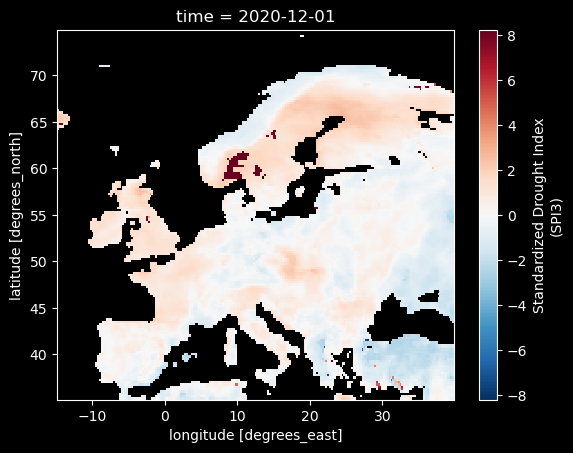

In [13]:
time_slice = cube.spi3.sel(time="2021-06-01 00:00:00", method="nearest")
time_slice.plot()

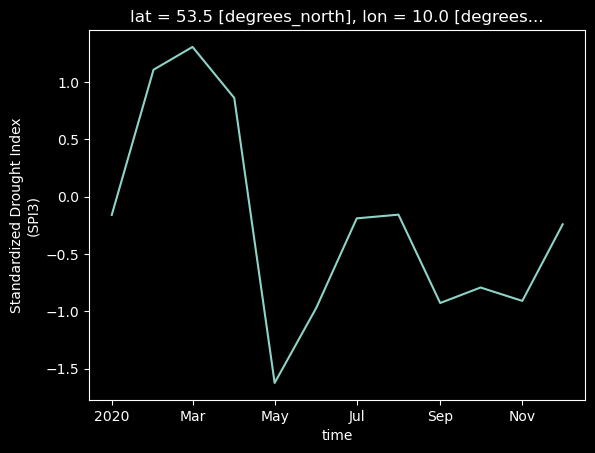

In [14]:
time_series = cube.spi3.sel(lat=53.5, lon=10., method="nearest")
time_series.plot()

We can also retrieve the 10 ensemble members in the following cell:

In [15]:
cube = cds_store.open_data(
    "derived-drought-historical-monthly:ensemble_members",
    variable_names=variable_names,
    accumulation_periods=accumulation_periods,
    bbox=bbox,
    time_range=time_range,
)

xcube-cds version 1.4.2.dev0
2026-07-13 14:35:22,904 INFO Request ID is 67f5b049-b2a5-403c-8e8c-6d23f6ee156e
2026-07-13 14:35:22,981 INFO status has been updated to accepted
2026-07-13 14:35:36,817 INFO status has been updated to running
2026-07-13 14:35:44,552 INFO status has been updated to successful


In [16]:
cube

<xarray.Dataset> Size: 501MB
Dimensions:             (time: 12, realization: 10, lat: 159, lon: 219)
Coordinates:
  * time                (time) datetime64[ns] 96B 2020-01-01 ... 2020-12-01
  * realization         (realization) int32 40B 1 2 3 4 5 6 7 8 9 10
  * lat                 (lat) float64 1kB 74.75 74.5 74.25 ... 35.75 35.5 35.25
  * lon                 (lon) float64 2kB -14.75 -14.5 -14.25 ... 39.5 39.75
Data variables: (12/15)
    spi1                (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spi3                (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spi6                (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spei1               (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spei3               (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spei6               (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    ...                  ...
    spi1_significance   (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spi3_significance   (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spi6_significance   (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spei1_significance  (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spei3_significance  (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
    spei6_significance  (time, realization, lat, lon) float64 33MB dask.array<chunksize=(1, 10, 159, 219), meta=np.ndarray>
Attributes: (12/14)
    CDI:                 Climate Data Interface version 1.9.10 (https://mpime...
    Conventions:         CF-1.8
    source:              DRYFALL v1.0
    institution:         European Centre for Medium-Range Weather Forecasts
    license:             Creative Commons Attribution v4
    citation_statement:  Drought indicators derived from ERA5 reanalysis
    ...                  ...
    resolution:          0.25x0.25
    climate_start_date:  1991-01-01
    climate_end_date:    2020-12-31
    frequency:           Monthly
    contact_person:      support@ecmwf.int
    CDO:                 Climate Data Operators version 1.9.10 (https://mpime...

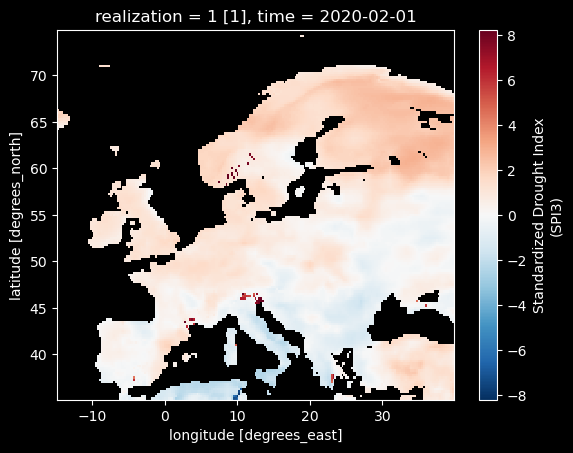

In [17]:
time_slice = cube.spi3.sel(time="2020-02-01 00:00:00", realization=0, method="nearest")
time_slice.plot()